# Knowledge Factor Investigation - Importance Computing

These are experimental codes:      
- Briefing the data
- Tuning optimal hyperparameter
- Visualize the performance of Models
- Visualize the importance
- Visualize and summerize impacts

In [88]:
%pwd

'/Users/lichao/Library/CloudStorage/OneDrive-Personal/MLD01_Article'

In [2]:
%cd ..

/Users/lichao/Library/CloudStorage/OneDrive-Personal/MLD01_Article


/Users/lichao/opt/anaconda3/envs/ML/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Import PAckage

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from xgboost import XGBClassifier 

## Append Data

In [4]:
df_2016 = pd.read_parquet('Data/01_Napel2016.parquet')
df_2016['Year'] = 2016
df_2022 = pd.read_parquet('Data/01_Napel2022.parquet')
df_2022['Year'] = 2022

In [5]:
df_all = pd.concat([df_2016, df_2022], axis = 0)

In [6]:
df_all.shape

(11568, 352)

In [7]:
df_all = df_all.dropna(axis=1, how="any")

In [8]:
df_all.shape

(11568, 277)

In [9]:
df_all = df_all.set_index(['PSU', 'HHLD'])

In [10]:
df_all.columns

Index(['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age',
       'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor',
       'Edu_Master',
       ...
       'SoilWaterConservationPast25', 'VisitClimateOfficePast25',
       'FoodConsumptionHabitPast25', 'OfffarmActiPast25',
       'NonFarmEmployPast25', 'FamilyMigrationPast25', 'RiskReductionPast25',
       'RoadImprovementPast25', 'CommunityPartipationPast25', 'Year'],
      dtype='object', length=275)

In [11]:
df_all["EcoBelt"] = df_all["EcoBelt"].str.replace('Tarai', 'Terai')

In [12]:
eco_dummies = pd.get_dummies(df_all["EcoBelt"], prefix="EcoBelt").astype(int)
df_all = pd.concat([df_all, eco_dummies], axis=1)

In [13]:
prov_dummies = pd.get_dummies(df_all["Prov"], prefix="Prov").astype(int)
df_all = pd.concat([df_all, prov_dummies], axis=1)

In [14]:
df_all

EcoBelt          Prov  Rural_Dummy  Respon_Female  Respon_Age  \
PSU   HHLD                                                                   
101.0 1.0   Mountain         Koshi            1            1.0        49.0   
      2.0   Mountain         Koshi            1            0.0        55.0   
      3.0   Mountain         Koshi            1            1.0        46.0   
      4.0   Mountain         Koshi            1            0.0        78.0   
      5.0   Mountain         Koshi            1            0.0        70.0   
...              ...           ...          ...            ...         ...   
826.0 16.0     Terai  Sudurpaschim            0            0.0        47.0   
      17.0     Terai  Sudurpaschim            0            0.0        60.0   
      18.0     Terai  Sudurpaschim            0            1.0        47.0   
      19.0     Terai  Sudurpaschim            0            0.0        55.0   
      20.0     Terai  Sudurpaschim            0            0.0        45.0   

            LivingYear  Edu_UnderSLC  Edu_Certificate  Edu_Bachelor  \
PSU   HHLD                                                            
101.0 1.0         49.0             0                0             0   
      2.0         55.0             1                0             0   
      3.0         25.0             0                0             0   
      4.0         78.0             0                0             0   
      5.0         70.0             1                0             0   
...                ...           ...              ...           ...   
826.0 16.0        40.0             1                0             0   
      17.0        35.0             0                0             0   
      18.0        32.0             1                0             0   
      19.0        55.0             0                0             0   
      20.0        25.0             1                0             0   

            Edu_Master  ...  EcoBelt_Hill  EcoBelt_Mountain  EcoBelt_Terai  \
PSU   HHLD              ...                                                  
101.0 1.0            0  ...             0                 1              0   
      2.0            0  ...             0                 1              0   
      3.0            0  ...             0                 1              0   
      4.0            0  ...             0                 1              0   
      5.0            0  ...             0                 1              0   
...                ...  ...           ...               ...            ...   
826.0 16.0           0  ...             0                 0              1   
      17.0           0  ...             0                 0              1   
      18.0           0  ...             0                 0              1   
      19.0           0  ...             0                 0              1   
      20.0           0  ...             0                 0              1   

            Prov_Bagmati  Prov_Gandaki  Prov_Karnali  Prov_Koshi  \
PSU   HHLD                                                         
101.0 1.0              0             0             0           1   
      2.0              0             0             0           1   
      3.0              0             0             0           1   
      4.0              0             0             0           1   
      5.0              0             0             0           1   
...                  ...           ...           ...         ...   
826.0 16.0             0             0             0           0   
      17.0             0             0             0           0   
      18.0             0             0             0           0   
      19.0             0             0             0           0   
      20.0             0             0             0           0   

            Prov_Lumbini  Prov_Madhesh  Prov_Sudurpaschim  
PSU   HHLD                                                 
101.0 1.0              0             0                

### Revise Income Resources

In [15]:
df_all['IncomeResAgri_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 1).any(axis=1).astype(int)
df_all['IncomeResWage_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 2).any(axis=1).astype(int)
df_all['IncomeResNonAgriBusi_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 3).any(axis=1).astype(int)
df_all['IncomeResRemit_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 4).any(axis=1).astype(int)
df_all['IncomeResOthers_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 5).any(axis=1).astype(int)

In [16]:
df_all['ResidenceOwn_dummy'] = (df_all['Own_Resid'] == 1).astype(int)
df_all['ResidenceRent_dummy'] = (df_all['Own_Resid'] == 2).astype(int)
df_all['ResidenceInstitu_dummy'] = (df_all['Own_Resid'] == 3).astype(int)
df_all['ResidenceOthers_dummy'] = (df_all['Own_Resid'] == 4).astype(int)

In [17]:
df_all['ResidInfraPerman_dummy'] = (df_all['Resid_Type'] == 1).astype(int)
df_all['ResidInfraSemi_dummy'] = (df_all['Resid_Type'] == 2).astype(int)
df_all['ResidInfraKachchi_dummy'] = (df_all['Resid_Type'] == 3).astype(int)
df_all['ResidInfraOthers_dummy'] = (df_all['Resid_Type'] == 4).astype(int)

## Checking "HeardClimate_Dummy"

### Dataset building

In [18]:
for here in range(0, df_all.shape[1], 40):
    print(df_all.columns[0+here:40+here])

Index(['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age',
       'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor',
       'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year',
       'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio',
       'Literal_Ratio', 'Household_memberNum', 'Own_Resid', 'Resid_Type',
       'WaterS1', 'WaterS2', 'WaterS3', 'CookFuelS1', 'CookFuelS2',
       'CookFuelS3', 'LightEnergy', 'Toilet', 'IncomeS1', 'IncomeS2',
       'IncomeS3', 'Remittance_dummy', 'Have_AgriLand', 'Radio_dummy',
       'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy'],
      dtype='object')
Index(['Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy',
       'OtherVehi_dummy', 'Refrige_dummy', 'HouseHead_AgriExpYear',
       'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport',
       'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market',
       'Dist_AgriSupport', 'FramMechan', 'CropIncome', 'L

In [19]:
df_inuse = df_all[['HeardClimate_Dummy', 
                   'Respon_Female', 'Respon_Age', 'LivingYear',  'Edu_Literal', 'Edu_Illiterate', 'Edu_year', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 
                   'Prov_Bagmati', 'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
                   'Prov_Gandaki', 'Prov_Karnali', # location     
                   'ResidenceOwn_dummy', 'ResidenceRent_dummy', 'ResidenceInstitu_dummy', 'ResidenceOthers_dummy',
                   'ResidInfraPerman_dummy', 'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy', 'ResidInfraOthers_dummy', # house
                    'Remittance_dummy', 
                   'Have_AgriLand', 'HouseHead_AgriExpYear',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 
                   'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 
                   'FramMechan',
                    'IncomeResAgri_dummy', 'IncomeResWage_dummy', 'IncomeResNonAgriBusi_dummy', 'IncomeResRemit_dummy',
                   'IncomeResOthers_dummy', 
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome',
                   'Year']]

In [20]:
variname_readable = {'HeardClimate_Dummy':'Heard about Climate Change Dummy', 'Respon_Female':'Female Dummy', 
                     'Respon_Age':'Age', 'LivingYear':'Years Living in Community', 'Edu_UnderSLC':'Education under Secondary Certificate Dummy', 
                     'Edu_Certificate':'Education with Secondary Certificate Dummy', 'Edu_Bachelor':'Education with Bachelor Dummy', 
                     'Edu_Master':'Education with Master Dummy',  'Edu_PhD':'Education with PhD Dummy', 
                     'Edu_Literal':'Literate Education Dummy',  'Edu_Illiterate':'Illiterate Dummy', 'Edu_year':'Education Year',
                     'Female_Ratio':'Female Ratio in Household', 'U18_Ratio':'Member Under 18 Ratio', 'A65_Ratio':'Seniors Ratio',
                     'Edu12_Ratio':"Member with 12-Year Education or above Ratio", "Literal_Ratio": "Literate Member Ratio",
                     'EcoBelt_Hill': "EcoBelt Hill Dummy", 'EcoBelt_Mountain': "EcoBelt Mountain Dummy", 'EcoBelt_Terai': "EcoBelt Terai Dummy",
                     'Prov_Bagmati': "Province Bagmati Dummy", 'Prov_Koshi': "Province Koshi Dummy", 'Prov_Lumbini': "Province Lumbibi Dummy",
                     'Prov_Madhesh': "Province Madhesh Dummy", 'Prov_Sudurpaschim': "Province Sudurpaschim Dummy", 'Prov_Gandaki': "Province Gandaki Dummy",
                     'Prov_Karnali': "Province Karnali Dummy",
                     'ResidenceOwn_dummy': "Owned Residence Ownership Dummy", 'ResidenceRent_dummy': 'Rented Residence Ownership Dummy', 
                     'ResidenceInstitu_dummy': 'Institutional Residence Ownership Dummy', 'ResidenceOthers_dummy': 'Other-type Residence Ownership Dummy',
                     'ResidInfraPerman_dummy': 'Permanent Residence Dummy', 'ResidInfraSemi_dummy': 'Semi-Permanent Residence Dummy', 
                     'ResidInfraKachchi_dummy': "Kachchi Residence Dummy", 'ResidInfraOthers_dummy': 'Other Residence Infrastructure Dummy', # house
                     'Remittance_dummy' : "Have Remittance",
                     'Have_AgriLand': "Having Agricultural Land Dummy", 'HouseHead_AgriExpYear': "Household Head Agricultural Experience",
                     'Radio_dummy': "Having Radio Dummy", 'TV_dummy': "Having TV Dummy", 'PC_dummy': "Having Computer Dummy", 'Net_dummy': "Having Internet Dummy",
                     'Phone_dummy': "Having Telephone Dummy", 'Mobile_dummy': "Having Mobile Dummy", 'Motorbike_dummy': "Having Motorbike Dummy", 
                     'Car_dummy': "Having Car Dummy", 'Bike_dummy': "Having Bike Dummy", 'OtherVehi_dummy': "Having Other Vehicle Dummy", 
                     'Refrige_dummy':"Having Refrigator Dummy",
                     'SavingMembership': "Saving Membership Dummy", 'RegularSaving': 'Having Regular Saving Dummy', 
                     'OrgMembership': 'Having Organization Membership Dummy', 'AgriSupport':'Agricultural Supporting Dummy', 
                     'Dist_Road': 'Distance to Motorable Road', 'Dist_HealthCenter': "Distance to Health Center", 
                     'Dist_SecondarySchool': "Distance to Secondary School", 'Dist_Market':"Distance to Market", 'Dist_AgriSupport': 'Distance to Agricultural Center', 
                     'FramMechan':'Farm Mechanization Dummy',
                     'IncomeResAgri_dummy': "Agricultural Income Source Dummy", 'IncomeResWage_dummy': "Wage Income Source Dummy",
                     'IncomeResNonAgriBusi_dummy': "Non-Agricultural Business Income Source Dummy", 'IncomeResRemit_dummy': "Remittance Income Dummy",
                     'IncomeResOthers_dummy': "Others Income Source Dummy", 
                     'CropIncome': "Crop Income", 'LivestockIncome': "Livestock Income", 'NonAgriIncome': "Non-agricultural Income", 
                     'BusiIncome': "Business Income", 'TotalIncome': "Total Income",
                     'Year': "Survey Year"                    
                    }

In [21]:
data_summary = df_inuse.describe().T

In [22]:
data_summary.index = data_summary.index.map(variname_readable)

In [23]:
data_summary.to_excel("MLD01e_Results/Table01_DataSummaryForKnowledge_v1.xlsx")

In [24]:
df_inuse.columns = df_inuse.columns.map(variname_readable)

In [25]:
data_summary

,count,mean,std,min,25%,50%,75%,max
Heard about Climate Change Dummy,11568.0,0.421508,4.938219e-01,0.0,0.0,0.0,1.0,1.0
Female Dummy,11568.0,0.285183,4.515212e-01,0.0,0.0,0.0,1.0,1.0
Age,11568.0,58.681189,1.027651e+01,45.0,50.0,58.0,66.0,95.0
Years Living in Community,11568.0,50.082382,1.582942e+01,25.0,40.0,50.0,60.0,730.0
Literate Education Dummy,11568.0,0.169001,3.747687e-01,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
Livestock Income,11568.0,15559.887275,9.565885e+04,0.0,0.0,0.0,15000.0,7200000.0
Non-agricultural Income,11568.0,79973.158368,2.710275e+05,0.0,0.0,0.0,50000.0,10000000.0
Business Income,11568.0,202175.389004,1.112664e+06,0.0,0.0,15000.0,240000.0,99000000.0
Total Income,11568.0,323942.349066,1.143592e+06,0.0,54000.0,170000.0,400000.0,99200000.0


In [26]:
cvres = pd.read_parquet('MLD01e_Results/MLD01e_C01_KnowledgeFactorInvestigation.parquet')

In [69]:
cvres.sort_values('rank_test_score').iloc[0,:]

mean_fit_time                                                      2.661557
std_fit_time                                                       0.133185
mean_score_time                                                    0.018475
std_score_time                                                     0.003636
param_subsample                                                         0.7
param_n_estimators                                                      500
param_min_child_weight                                                    5
param_max_depth                                                           8
param_learning_rate                                                    0.01
param_colsample_bytree                                                  0.7
params                    {'colsample_bytree': 0.7, 'learning_rate': 0.0...
split0_test_score                                                   0.75108
split1_test_score                                                  0.760588
split2_test_

In [70]:
params = cvres.sort_values('rank_test_score').iloc[0,10]

In [71]:
params

{'colsample_bytree': 0.7,
 'learning_rate': 0.01,
 'max_depth': 8,
 'min_child_weight': 5,
 'n_estimators': 500,
 'subsample': 0.7}

## 10-fold 10-epoch Estimation

In [72]:
def Metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

    return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]

In [89]:
y = df_inuse['Heard about Climate Change Dummy'].astype(int)
X = df_inuse.drop(columns=['Heard about Climate Change Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [75]:
acc_lines = []
importances_df = []

for random_seed in range(42, 42*11, 42):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
    
    
        metrics = Metrics(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred).flatten()
        line  = [fold, random_seed] + metrics + list(cm)
        importances = clf.feature_importances_
    
        acc_lines.append(line)
        importances_df.append(importances)

fold: 1, random_seed:42
Accuracy: 0.7467588591184097
Precision: 0.6963562753036437
Recall   : 0.7063655030800822
F1-score : 0.7013251783893986
fold: 2, random_seed:42
Accuracy: 0.766637856525497
Precision: 0.7237113402061855
Recall   : 0.7207392197125256
F1-score : 0.7222222222222222
fold: 3, random_seed:42
Accuracy: 0.7631806395851339
Precision: 0.717479674796748
Recall   : 0.7233606557377049
F1-score : 0.7204081632653061
fold: 4, random_seed:42
Accuracy: 0.7536732929991357
Precision: 0.704225352112676
Recall   : 0.7172131147540983
F1-score : 0.7106598984771574
fold: 5, random_seed:42
Accuracy: 0.7683664649956785
Precision: 0.7217741935483871
Recall   : 0.7336065573770492
F1-score : 0.7276422764227642
fold: 6, random_seed:42
Accuracy: 0.7605877268798618
Precision: 0.7268817204301076
Recall   : 0.6926229508196722
F1-score : 0.7093389296956978
fold: 7, random_seed:42
Accuracy: 0.7778738115816768
Precision: 0.7431578947368421
Recall   : 0.7233606557377049
F1-score : 0.7331256490134995
fo

In [76]:
acc_df = pd.DataFrame(acc_lines)

In [77]:
acc_df.columns = ['fold', 'random_seed', 'acc', 'prec', 'recall', 'f1', 'TN', 'FP', 'FN', 'TP']

In [78]:
acc_df.to_excel('MLD01e_Results/Table02_AccuracyTable_Knowledge_v1.xlsx')

In [79]:
acc_df[['acc', 'prec', 'recall', 'f1']].mean(axis=0)

acc       0.759189
prec      0.713192
recall    0.717802
f1        0.715272
dtype: float64

In [80]:
import_df = pd.DataFrame(importances_df).T

In [81]:
import_df.index = X.columns

In [82]:
import_df['Mean_Importance'] = import_df.iloc[:,:100].mean(axis = 1)
import_df['Std_Importance'] = import_df.iloc[:,:100].std(axis = 1)

In [83]:
import_df['Mean_Importance'] 

Female Dummy                 0.012760
Age                          0.008600
Years Living in Community    0.009061
Literate Education Dummy     0.017381
Illiterate Dummy             0.082853
                               ...   
Livestock Income             0.009854
Non-agricultural Income      0.011512
Business Income              0.009361
Total Income                 0.010951
Survey Year                  0.029484
Name: Mean_Importance, Length: 64, dtype: float32

In [84]:
import_df.to_excel('MLD01e_Results/Table03_Importance_Knowledge_v1.xlsx')

In [85]:
# Get importance values
importances = pd.Series(import_df['Mean_Importance'] , index=import_df.index)

# Sort descending
importances = importances.sort_values(ascending=False)

print(importances.head(20))   # Top 20 important features

Illiterate Dummy                                0.082853
Education Year                                  0.080939
Having Computer Dummy                           0.070035
Having Telephone Dummy                          0.030462
Survey Year                                     0.029484
Having Mobile Dummy                             0.022415
Having Refrigator Dummy                         0.020488
Having TV Dummy                                 0.020159
Province Koshi Dummy                            0.019600
Member with 12-Year Education or above Ratio    0.019548
Having Other Vehicle Dummy                      0.018746
Province Karnali Dummy                          0.018581
EcoBelt Terai Dummy                             0.018189
Having Car Dummy                                0.017967
Literate Education Dummy                        0.017381
Farm Mechanization Dummy                        0.016544
Distance to Motorable Road                      0.015917
Province Madhesh Dummy         

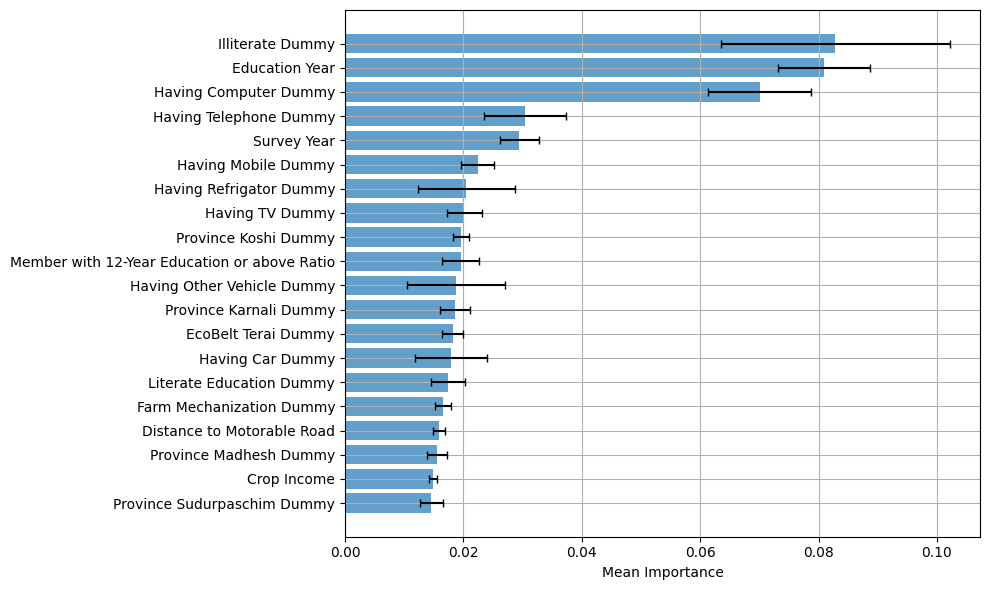

In [86]:
top20 = import_df.sort_values("Mean_Importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(
    top20.index, 
    top20["Mean_Importance"], 
    xerr=top20["Std_Importance"] * 1.96, 
    align="center", 
    alpha=0.7, 
    ecolor="black", 
    capsize=3
)
plt.xlabel("Mean Importance")
plt.grid()
plt.gca().invert_yaxis()  # largest on top
plt.tight_layout()

plt.savefig("MLD01e_Figures/FigX_Knowledge_Importance.jpg", dpi=300, bbox_inches="tight")

plt.show()

In [87]:
importances.head(20).index

Index(['Illiterate Dummy', 'Education Year', 'Having Computer Dummy',
       'Having Telephone Dummy', 'Survey Year', 'Having Mobile Dummy',
       'Having Refrigator Dummy', 'Having TV Dummy', 'Province Koshi Dummy',
       'Member with 12-Year Education or above Ratio',
       'Having Other Vehicle Dummy', 'Province Karnali Dummy',
       'EcoBelt Terai Dummy', 'Having Car Dummy', 'Literate Education Dummy',
       'Farm Mechanization Dummy', 'Distance to Motorable Road',
       'Province Madhesh Dummy', 'Crop Income', 'Province Sudurpaschim Dummy'],
      dtype='object')